# 05 - Latent Regime Follow-Up

This notebook replaces the observed-state oracle benchmark with a more realistic hidden-state setting.

The true world still switches between calm and stress correlation regimes, but the hedger no longer observes the current state directly. Instead, it only sees past multivariate returns and updates the posterior stress probability

$$
\pi_t = P(X_t = 1 \mid \mathcal{F}^{\text{returns}}_t).
$$

**Comparison.** The notebook evaluates four positions:

1. an unhedged short option;
2. a constant-correlation hedge;
3. an oracle regime hedge that knows the true hidden state;
4. a filtered regime hedge that uses posterior-weighted regime deltas.

**Question.** How much of the oracle regime-hedge advantage survives once the calm/stress state becomes latent rather than directly observed?

This notebook therefore separates two distinct effects: the value of using a regime model at all, and the loss from not observing the regime perfectly.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# Resolve repository paths so the notebook works from a clone or a ZIP extract.

def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (
            (candidate / "README.md").exists()
            and (candidate / "notebooks").is_dir()
            and (candidate / "scripts").is_dir()
        ):
            return candidate
    raise FileNotFoundError("Could not locate the project root. Run from inside the repository.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "outputs" / "latent_regime"
DATA_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))

from synthetic_analysis_utils import (
    average_off_diagonal,
    build_transition_matrix,
    equicorrelation_matrix,
    simulate_regime_switching_paths,
    summary_frame_from_results,
)
from latent_regime_utils import (
    filter_diagnostics,
    filtered_stress_probabilities,
    scenario_results,
)

In [2]:
spot = np.array([100.0, 95.0, 110.0])
weights = np.array([0.40, 0.35, 0.25])
vol = np.array([0.20, 0.25, 0.22])
div_yield = np.zeros_like(spot)

rate = 0.03
maturity = 1.0
strike = float(weights @ spot)
bump_fraction = 0.01
n_true_world_paths = 220
delta_mc_paths = 1500
initial_price_mc_paths = 15000
n_repeats = 3
start_regime = 0

scenario_specs = [
    {
        "scenario": "Baseline",
        "description": "Original synthetic benchmark",
        "rho_constant": 0.35,
        "rho_calm": 0.20,
        "rho_stress": 0.75,
        "p01_daily": 0.03,
        "p10_daily": 0.12,
        "hedge_steps": 12,
    },
    {
        "scenario": "Latent stress",
        "description": "Monthly high-stress benchmark with 50% stress share and symmetric switching",
        "rho_constant": 0.35,
        "rho_calm": 0.20,
        "rho_stress": 0.98,
        "p01_daily": 0.06,
        "p10_daily": 0.06,
        "hedge_steps": 12,
    },
]

scenario_config = pd.DataFrame(scenario_specs)
scenario_config["stress_share_stationary"] = (
    scenario_config["p01_daily"] / (scenario_config["p01_daily"] + scenario_config["p10_daily"])
)
display(Markdown("## Scenario setup"))
display(Markdown(f"Averaging over **{n_repeats}** independent true-world repeats per scenario."))
display(scenario_config)

## Scenario setup

Averaging over **3** independent true-world repeats per scenario.

,scenario,description,rho_constant,rho_calm,rho_stress,p01_daily,p10_daily,hedge_steps,stress_share_stationary
0,Baseline,Original synthetic benchmark,0.3500,0.2000,0.7500,0.0300,0.1200,12,0.2000
1,Latent stress,Monthly high-stress benchmark with 50% stress ...,0.3500,0.2000,0.9800,0.0600,0.0600,12,0.5000


In [3]:
raw_summary_frames = []
raw_filter_rows = []
recovery_rows = []
pathwise_rows = []
sample_path_rows = []

for idx, spec in enumerate(scenario_specs):
    hedge_steps = int(spec["hedge_steps"])
    hedge_dt = maturity / hedge_steps

    corr_constant = equicorrelation_matrix(len(spot), spec["rho_constant"])
    corr_calm = equicorrelation_matrix(len(spot), spec["rho_calm"])
    corr_stress = equicorrelation_matrix(len(spot), spec["rho_stress"])

    transition_daily = build_transition_matrix(spec["p01_daily"], spec["p10_daily"])
    transition_hedge = np.linalg.matrix_power(transition_daily, 252 // hedge_steps)
    pricing_inputs = {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps,
        "hedge_dt": hedge_dt,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": np.linalg.cholesky(corr_constant),
        "chol_calm": np.linalg.cholesky(corr_calm),
        "chol_stress": np.linalg.cholesky(corr_stress),
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }

    for repeat in range(n_repeats):
        true_paths, true_regimes = simulate_regime_switching_paths(
            spot=spot,
            rate=rate,
            div_yield=div_yield,
            vol=vol,
            maturity=maturity,
            n_steps=hedge_steps,
            n_paths=n_true_world_paths,
            corr_calm=corr_calm,
            corr_stress=corr_stress,
            transition_matrix=transition_hedge,
            start_regime=start_regime,
            seed=2026032100 + 1000 * idx + repeat,
        )

        filtered_priors, filtered_posteriors = filtered_stress_probabilities(
            true_paths=true_paths,
            rate=rate,
            div_yield=div_yield,
            vol=vol,
            corr_calm=corr_calm,
            corr_stress=corr_stress,
            transition_hedge=transition_hedge,
            initial_stress_probability=float(start_regime),
            hedge_dt=hedge_dt,
        )

        results, pnls, deltas = scenario_results(
            true_paths=true_paths,
            true_regimes=true_regimes,
            filtered_priors=filtered_priors,
            pricing_inputs=pricing_inputs,
            base_seed=2026032500 + 1000 * idx + repeat,
        )

        frame = summary_frame_from_results(results)
        frame["scenario"] = spec["scenario"]
        frame["description"] = spec["description"]
        frame["repeat"] = repeat
        frame["avg_stress_fraction"] = float(true_regimes.mean())
        frame["avg_prior_stress_probability"] = float(filtered_priors.mean())
        frame["avg_posterior_stress_probability"] = float(filtered_posteriors.mean())
        raw_summary_frames.append(frame)

        diag = filter_diagnostics(filtered_priors, true_regimes)
        diag.update(
            {
                "scenario": spec["scenario"],
                "description": spec["description"],
                "repeat": repeat,
                "rho_constant": spec["rho_constant"],
                "rho_calm": spec["rho_calm"],
                "rho_stress": spec["rho_stress"],
                "avg_offdiag_constant": average_off_diagonal(corr_constant),
                "avg_offdiag_calm": average_off_diagonal(corr_calm),
                "avg_offdiag_stress": average_off_diagonal(corr_stress),
            }
        )
        raw_filter_rows.append(diag)

        if repeat == 0:
            pathwise = pd.DataFrame(
                {
                    "scenario": spec["scenario"],
                    "repeat": repeat,
                    "path_id": np.arange(n_true_world_paths),
                    "stress_fraction": true_regimes.mean(axis=1),
                    "avg_prior_stress_probability": filtered_priors.mean(axis=1),
                    "avg_posterior_stress_probability": filtered_posteriors.mean(axis=1),
                    "Unhedged short option": pnls["Unhedged short option"],
                    "Constant-correlation hedge": pnls["Constant-correlation hedge"],
                    "Oracle regime hedge": pnls["Oracle regime hedge"],
                    "Filtered regime hedge": pnls["Filtered regime hedge"],
                }
            )
            pathwise_rows.append(pathwise)

            sample_ids = (
                pd.Series(true_regimes.mean(axis=1))
                .sort_values(ascending=False)
                .head(3)
                .index
                .tolist()
            )
            for path_id in sample_ids:
                for step in range(hedge_steps):
                    sample_path_rows.append(
                        {
                            "scenario": spec["scenario"],
                            "repeat": repeat,
                            "path_id": int(path_id),
                            "step": step,
                            "true_regime": int(true_regimes[path_id, step]),
                            "prior_stress_probability": float(filtered_priors[path_id, step]),
                            "posterior_stress_probability": float(filtered_posteriors[path_id, step]),
                        }
                    )

summary_raw_table = pd.concat(raw_summary_frames, ignore_index=True)
summary_table = (
    summary_raw_table.drop(columns=["repeat"])
    .groupby(["scenario", "description", "strategy"], as_index=False)
    .mean(numeric_only=True)
)

filter_diagnostics_raw_table = pd.DataFrame(raw_filter_rows)
filter_diagnostics_table = (
    filter_diagnostics_raw_table.drop(columns=["repeat"])
    .groupby(
        [
            "scenario",
            "description",
            "rho_constant",
            "rho_calm",
            "rho_stress",
            "avg_offdiag_constant",
            "avg_offdiag_calm",
            "avg_offdiag_stress",
        ],
        as_index=False,
    )
    .mean(numeric_only=True)
)

for spec in scenario_specs:
    scenario_slice = summary_table.loc[summary_table["scenario"] == spec["scenario"]].set_index("strategy")
    std_const = scenario_slice.loc["Constant-correlation hedge", "std_pnl"]
    std_oracle = scenario_slice.loc["Oracle regime hedge", "std_pnl"]
    std_filtered = scenario_slice.loc["Filtered regime hedge", "std_pnl"]
    q05_const = scenario_slice.loc["Constant-correlation hedge", "q05_pnl"]
    q05_oracle = scenario_slice.loc["Oracle regime hedge", "q05_pnl"]
    q05_filtered = scenario_slice.loc["Filtered regime hedge", "q05_pnl"]
    q01_const = scenario_slice.loc["Constant-correlation hedge", "q01_pnl"]
    q01_oracle = scenario_slice.loc["Oracle regime hedge", "q01_pnl"]
    q01_filtered = scenario_slice.loc["Filtered regime hedge", "q01_pnl"]

    recovery_rows.append(
        {
            "scenario": spec["scenario"],
            "std_advantage_oracle_vs_constant": std_const - std_oracle,
            "std_advantage_filtered_vs_constant": std_const - std_filtered,
            "std_recovery_fraction": (
                (std_const - std_filtered) / (std_const - std_oracle)
                if (std_const - std_oracle) > 1e-10
                else np.nan
            ),
            "q05_advantage_oracle_vs_constant": q05_oracle - q05_const,
            "q05_advantage_filtered_vs_constant": q05_filtered - q05_const,
            "q05_recovery_fraction": (
                (q05_filtered - q05_const) / (q05_oracle - q05_const)
                if (q05_oracle - q05_const) > 1e-10
                else np.nan
            ),
            "q01_advantage_oracle_vs_constant": q01_oracle - q01_const,
            "q01_advantage_filtered_vs_constant": q01_filtered - q01_const,
            "q01_recovery_fraction": (
                (q01_filtered - q01_const) / (q01_oracle - q01_const)
                if (q01_oracle - q01_const) > 1e-10
                else np.nan
            ),
        }
    )

recovery_table = pd.DataFrame(recovery_rows)
pathwise_table = pd.concat(pathwise_rows, ignore_index=True)
sample_paths_table = pd.DataFrame(sample_path_rows)

display(Markdown("## Hedging summary"))
display(
    summary_table[
        [
            "scenario",
            "strategy",
            "model_initial_price",
            "funding_initial_price",
            "std_pnl",
            "q05_pnl",
            "q01_pnl",
            "avg_stress_fraction",
        ]
    ]
)

display(Markdown("## Filter diagnostics"))
display(filter_diagnostics_table)

display(Markdown("## Recovery of oracle advantage"))
display(recovery_table)

## Hedging summary

,scenario,strategy,model_initial_price,funding_initial_price,std_pnl,q05_pnl,q01_pnl,avg_stress_fraction
0,Baseline,Constant-correlation hedge,8.2644,7.9626,1.5892,-3.0673,-4.6970,0.1784
1,Baseline,Filtered regime hedge,8.0503,7.9626,1.5700,-2.9801,-4.7960,0.1784
2,Baseline,Oracle regime hedge,7.9626,7.9626,1.5973,-2.9055,-4.7026,0.1784
3,Baseline,Unhedged short option,7.9626,7.9626,11.2027,-22.6460,-35.3969,0.1784
4,Latent stress,Constant-correlation hedge,8.2094,8.9429,1.9624,-3.3803,-6.0788,0.4520
5,Latent stress,Filtered regime hedge,8.9879,8.9429,1.9591,-3.3127,-5.5540,0.4520
6,Latent stress,Oracle regime hedge,8.9429,8.9429,1.9715,-3.1860,-5.2166,0.4520
7,Latent stress,Unhedged short option,8.9429,8.9429,13.0597,-25.5158,-43.8276,0.4520


## Filter diagnostics

,scenario,description,rho_constant,rho_calm,rho_stress,avg_offdiag_constant,avg_offdiag_calm,avg_offdiag_stress,mean_prior_stress,mean_prior_given_true_stress,mean_prior_given_true_calm,hard_classification_accuracy,brier_score
0,Baseline,Original synthetic benchmark,0.3500,0.2000,0.7500,0.3500,0.2000,0.7500,0.1827,0.1997,0.1790,0.8216,0.1436
1,Latent stress,Monthly high-stress benchmark with 50% stress ...,0.3500,0.2000,0.9800,0.3500,0.2000,0.9800,0.4550,0.4983,0.4192,0.5678,0.2283


## Recovery of oracle advantage

,scenario,std_advantage_oracle_vs_constant,std_advantage_filtered_vs_constant,std_recovery_fraction,q05_advantage_oracle_vs_constant,q05_advantage_filtered_vs_constant,q05_recovery_fraction,q01_advantage_oracle_vs_constant,q01_advantage_filtered_vs_constant,q01_recovery_fraction
0,Baseline,-0.0081,0.0192,NaN,0.1618,0.0873,0.5392,-0.0056,-0.0990,NaN
1,Latent stress,-0.0092,0.0032,NaN,0.1943,0.0675,0.3475,0.8622,0.5247,0.6086


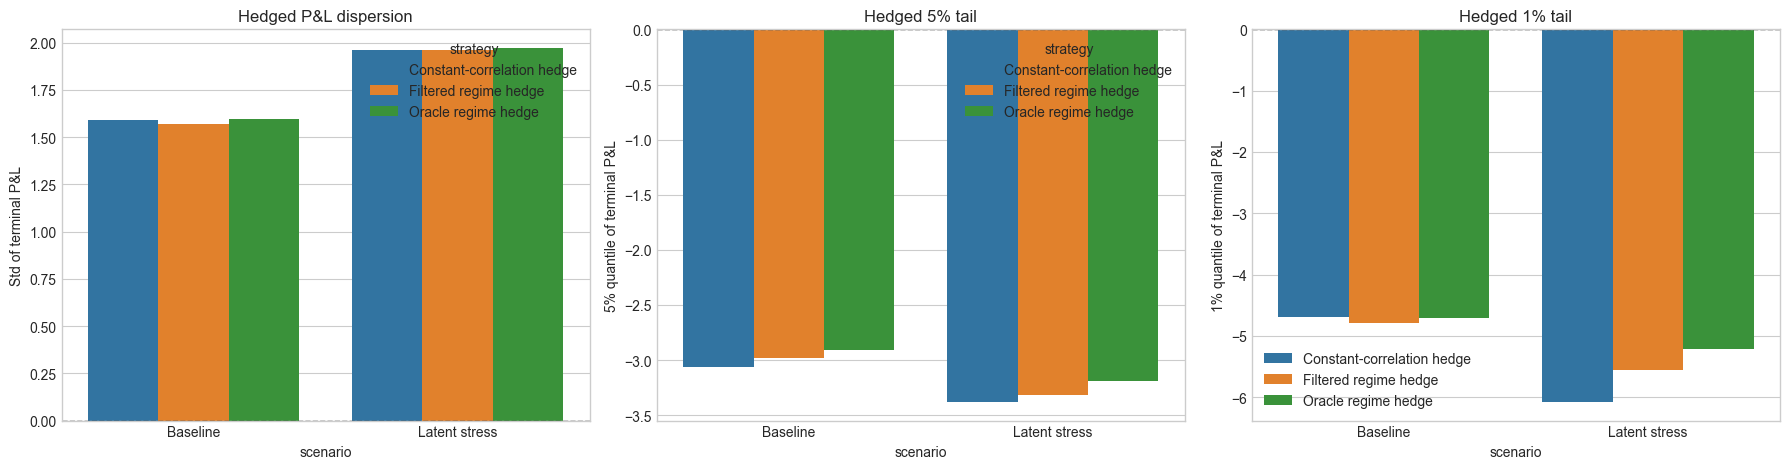

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=False)

sns.barplot(
    data=summary_table.loc[summary_table["strategy"] != "Unhedged short option"],
    x="scenario",
    y="std_pnl",
    hue="strategy",
    ax=axes[0],
)
axes[0].set_title("Hedged P&L dispersion")
axes[0].set_ylabel("Std of terminal P&L")

sns.barplot(
    data=summary_table.loc[summary_table["strategy"] != "Unhedged short option"],
    x="scenario",
    y="q05_pnl",
    hue="strategy",
    ax=axes[1],
)
axes[1].set_title("Hedged 5% tail")
axes[1].set_ylabel("5% quantile of terminal P&L")

sns.barplot(
    data=summary_table.loc[summary_table["strategy"] != "Unhedged short option"],
    x="scenario",
    y="q01_pnl",
    hue="strategy",
    ax=axes[2],
)
axes[2].set_title("Hedged 1% tail")
axes[2].set_ylabel("1% quantile of terminal P&L")

for ax in axes:
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[2].legend(loc="best")
plt.tight_layout()
plt.show()

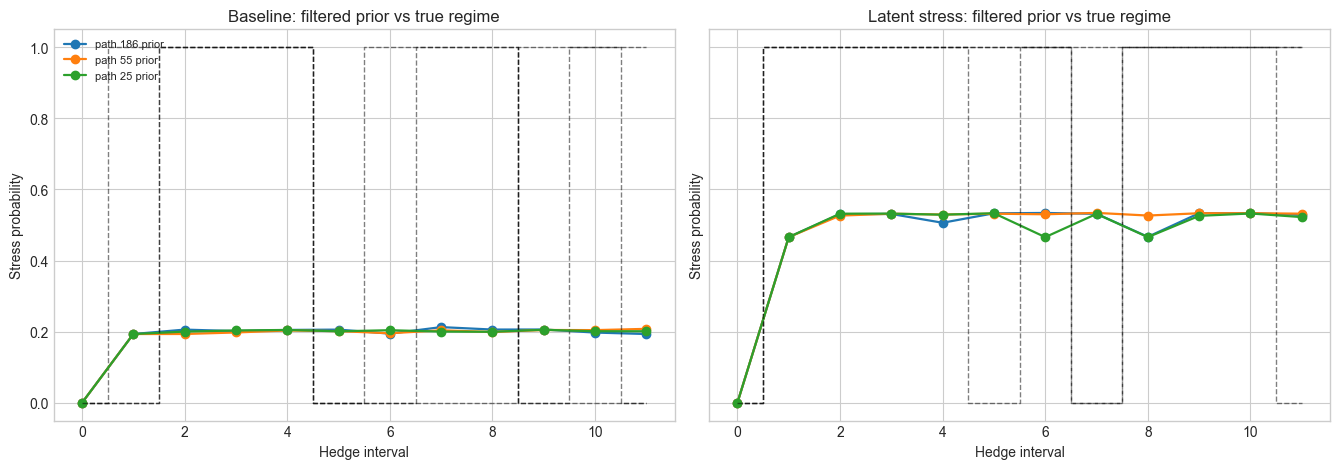

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharey=True)

for axis, scenario_name in zip(axes, [spec["scenario"] for spec in scenario_specs]):
    subset = sample_paths_table.loc[sample_paths_table["scenario"] == scenario_name]
    for path_id in subset["path_id"].unique():
        path_df = subset.loc[subset["path_id"] == path_id]
        axis.plot(
            path_df["step"],
            path_df["prior_stress_probability"],
            marker="o",
            linewidth=1.6,
            label=f"path {path_id} prior",
        )
        axis.step(
            path_df["step"],
            path_df["true_regime"],
            where="mid",
            linestyle="--",
            linewidth=1.0,
            color="black",
            alpha=0.5,
        )
    axis.set_title(f"{scenario_name}: filtered prior vs true regime")
    axis.set_xlabel("Hedge interval")
    axis.set_ylabel("Stress probability")
    axis.set_ylim(-0.05, 1.05)

axes[0].legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

In [6]:
summary_raw_path = DATA_DIR / "latent_filtered_hedging_raw.csv"
summary_path = DATA_DIR / "latent_filtered_hedging_summary.csv"
diagnostics_raw_path = DATA_DIR / "latent_filtered_filter_diagnostics_raw.csv"
diagnostics_path = DATA_DIR / "latent_filtered_filter_diagnostics.csv"
recovery_path = DATA_DIR / "latent_filtered_recovery.csv"
pathwise_path = DATA_DIR / "latent_filtered_pathwise_pnl.csv"
sample_paths_path = DATA_DIR / "latent_filtered_sample_paths.csv"

summary_raw_table.to_csv(summary_raw_path, index=False)
summary_table.to_csv(summary_path, index=False)
filter_diagnostics_raw_table.to_csv(diagnostics_raw_path, index=False)
filter_diagnostics_table.to_csv(diagnostics_path, index=False)
recovery_table.to_csv(recovery_path, index=False)
pathwise_table.to_csv(pathwise_path, index=False)
sample_paths_table.to_csv(sample_paths_path, index=False)

print(f"Saved raw hedging summary to {summary_raw_path}")
print(f"Saved hedging summary to {summary_path}")
print(f"Saved raw filter diagnostics to {diagnostics_raw_path}")
print(f"Saved filter diagnostics to {diagnostics_path}")
print(f"Saved oracle-recovery table to {recovery_path}")
print(f"Saved pathwise P&L to {pathwise_path}")
print(f"Saved sample path probabilities to {sample_paths_path}")

Saved raw hedging summary to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_hedging_raw.csv
Saved hedging summary to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_hedging_summary.csv
Saved raw filter diagnostics to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_filter_diagnostics_raw.csv
Saved filter diagnostics to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_filter_diagnostics.csv
Saved oracle-recovery table to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_recovery.csv
Saved pathwise P&L to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_pathwise_pnl.csv
Saved sample path probabilities to /Users/hamzaahmed/Multi-Asset Option Pricing/outputs/latent_regime/latent_filtered_sample_paths.csv


## Reading the result

The key interpretation is:

- `Constant-correlation hedge`: ignores the regime entirely
- `Oracle regime hedge`: knows the true hidden state
- `Filtered regime hedge`: only sees past returns and updates a posterior stress probability

The filtered hedge is the realistic version of the regime model. If it lands between constant and oracle, then the project gets a clean decomposition:

- `constant -> oracle`: total value of the regime model
- `filtered -> oracle`: cost of latent-state uncertainty
- `constant -> filtered`: implementable gain from filtering the hidden state

In the stronger latent-stress scenario, the main question is whether the filtered hedge preserves most of the oracle improvement once the true state is hidden.